# 📘 S3_P1 — Admission MBA : régression logistique et classes déséquilibrées

## 🎯 Ce que tu vas apprendre
1. Nettoyer un dataset réel : valeurs manquantes, hypothèses métier
2. Encoder des variables binaires avec `map`
3. Entraîner une régression logistique
4. **Découvrir pourquoi l'accuracy ment quand les classes sont déséquilibrées**
5. Détecter un piège subtil : l'ordre des arguments de `classification_report`

## 🚨 LE point crucial de ce notebook : les classes déséquilibrées

Après nettoyage, le dataset contient **5194 refus (« Deny ») pour seulement 900 admissions (« Admit »)** — soit ≈ **85 % / 15 %**.

**Pourquoi c'est un piège énorme :** un « modèle » stupide qui répond TOUJOURS « refusé » obtient déjà **85 % d'accuracy** sans rien apprendre ! Sur ce genre de données :
- l'**accuracy est trompeuse** (elle récompense le pari sur la classe majoritaire),
- il FAUT regarder la **précision et le rappel de la classe minoritaire** (« Admit »),
- garde ce chiffre de 85 % en tête à CHAQUE métrique que tu liras plus bas.

---
Import de pandas.

In [92]:
import pandas as pd

Chargement de `MBA.csv` : 6194 candidatures à un programme MBA, avec le profil de chaque candidat (genre, GPA, score GMAT, expérience professionnelle…) et la décision d'admission.

In [93]:
data = pd.read_csv("MBA.csv")

**Exploration :** repère la colonne cible `admission` — remarque qu'elle contient des `NaN` (valeurs manquantes) : première chose à traiter. Colonnes disponibles : `application_id`, `gender`, `international`, `gpa`, `major`, `race`, `gmat`, `work_exp`, `work_industry`, `admission`.

In [94]:
data

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN
2,3,Female,True,3.30,Business,NaN,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,NaN
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN
...,...,...,...,...,...,...,...,...,...,...
6189,6190,Male,False,3.49,Business,White,640.0,5.0,Other,NaN
6190,6191,Male,False,3.18,STEM,Black,670.0,4.0,Consulting,NaN
6191,6192,Female,True,3.22,Business,NaN,680.0,5.0,Health Care,Admit
6192,6193,Male,True,3.36,Business,NaN,590.0,5.0,Other,NaN


## DATA PREPROCESSING

## Étape 1 — L'inventaire des valeurs manquantes

`data.isna().sum()` compte les `NaN` par colonne : **`race` → 1842** et **`admission` → 5194** ! Plus de la moitié des candidats n'ont pas de statut d'admission renseigné. Avant tout modèle, il faut décider quoi en faire — c'est l'objet de l'étape 2.

In [95]:
data.isna().sum()

application_id       0
gender               0
international        0
gpa                  0
major                0
race              1842
gmat                 0
work_exp             0
work_industry        0
admission         5194
dtype: int64

## Étape 2 — Deux imputations basées sur des hypothèses MÉTIER

**Ce que fait le code :**
- `data["race"].fillna("International")` → hypothèse : les candidats sans origine ethnique renseignée sont des internationaux (aux USA, cette question du formulaire est souvent réservée aux résidents — les internationaux la sautent).
- `data["admission"].fillna("Deny")` → hypothèse : pas de décision enregistrée = refus.

**⚠️ Esprit critique :** ce sont des **hypothèses**, pas des faits vérifiés. Si certains `NaN` d'`admission` correspondent en réalité à des dossiers incomplets ou retirés (et non des refus), le modèle apprendra sur des étiquettes partiellement fausses. En pratique professionnelle, on chercherait à vérifier ces hypothèses auprès de la source des données. Ici on les accepte pour avancer — mais souviens-t'en si les résultats déçoivent.

In [96]:
data["race"] = data["race"].fillna("International")
data["admission"] = data["admission"].fillna("Deny")
data.isna().sum()

application_id    0
gender            0
international     0
gpa               0
major             0
race              0
gmat              0
work_exp          0
work_industry     0
admission         0
dtype: int64

`value_counts()` compte chaque valeur de la colonne : **5194 Deny / 900 Admit / 100 Waitlist**. C'est ici qu'on découvre le déséquilibre massif annoncé en intro.

In [97]:
data["admission"].value_counts()

admission
Deny        5194
Admit        900
Waitlist     100
Name: count, dtype: int64

## Étape 3 — Retirer les « Waitlist » : passer en binaire

`data[data["admission"] != "Waitlist"]` garde les lignes dont le statut n'est PAS « liste d'attente » — on passe de 3 classes à **2** (classification binaire, plus simple).

**Le coût de cette simplification :** on jette 100 dossiers « limites » — précisément les cas les plus intéressants à comprendre pour une école ! Choix pédagogique acceptable, mais dans la vraie vie on se poserait la question.

In [98]:
data = data[data["admission"] != "Waitlist"]

**Vérification :** 5194 Deny / 900 Admit. Le ratio 85/15 est confirmé.

In [99]:
data["admission"].value_counts()

admission
Deny     5194
Admit     900
Name: count, dtype: int64

Aperçu du tableau après filtrage.

In [100]:
data.head()

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,Deny
2,3,Female,True,3.30,Business,International,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,Deny
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,Deny


## Étape 4 — Écarter les colonnes catégorielles complexes

`drop(columns=["major","race","work_industry"])` supprime 3 colonnes de **texte à plusieurs valeurs** (filière, origine, secteur d'activité). Pour les utiliser, il aurait fallu un `get_dummies` (comme en S2_P4) créant beaucoup de colonnes. **Simplification assumée** — au prix d'informations potentiellement prédictives (certains secteurs d'activité mènent peut-être plus souvent au MBA !).

In [101]:
data = data.drop(columns=["major","race","work_industry"])

Vérification : il reste 7 colonnes, dont 2 encore non numériques (`gender` texte, `international` booléen) — traitées dans les 2 cellules suivantes.

In [102]:
data.head()

,application_id,gender,international,gpa,gmat,work_exp,admission
0,1,Female,False,3.30,620.0,3.0,Admit
1,2,Male,False,3.28,680.0,5.0,Deny
2,3,Female,True,3.30,710.0,5.0,Admit
3,4,Male,False,3.47,690.0,6.0,Deny
4,5,Male,False,3.35,590.0,5.0,Deny


## Étape 5 — Encoder les variables binaires avec `map`

**Ce que fait le code :** `.map({"Male":0, "Female":1})` remplace chaque valeur selon le dictionnaire : Male→0, Female→1. Idem pour `admission` : Admit→1, Deny→0.

**💡 `map` vs `get_dummies` :** pour une variable à exactement **2 valeurs**, un simple `map` vers 0/1 suffit (une seule colonne). `get_dummies` ne devient nécessaire qu'à partir de 3 valeurs et plus. Note la convention : la classe « positive » (celle qu'on cherche à détecter — être admis) reçoit le **1**.

In [103]:
data["gender"] = data["gender"].map({"Male":0,"Female":1})
data["admission"] = data["admission"].map({"Admit":1,"Deny":0})

data.head()

,application_id,gender,international,gpa,gmat,work_exp,admission
0,1,1,False,3.30,620.0,3.0,1
1,2,0,False,3.28,680.0,5.0,0
2,3,1,True,3.30,710.0,5.0,1
3,4,0,False,3.47,690.0,6.0,0
4,5,0,False,3.35,590.0,5.0,0


`international` est un booléen (`True`/`False`) : `.astype(int)` le convertit en 1/0 — uniformisation des types pour sklearn.

In [104]:
data["international"] = data["international"].astype(int)

## TEST AND TRAIN SPLIT

Import de `train_test_split` (le split en une ligne, cf. S2_P3).

In [105]:
from sklearn.model_selection import train_test_split

**Features / cible :** `X = data.drop("admission", axis=1)` (tout sauf la cible) et `y = data["admission"]`.

💡 **Détail critiquable :** `application_id` (le numéro de dossier) reste dans X ! Un identifiant arbitraire n'a aucun pouvoir prédictif légitime — au mieux il ne sert à rien, au pire le modèle y trouve des motifs accidentels. Dans l'idéal : `data.drop(["admission","application_id"], axis=1)`.

In [106]:
X = data.drop("admission",axis = 1)
y = data["admission"]

Split 80/20, `random_state=32`. Le test contiendra 1219 candidats.

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=32)

## Fit & Predict

**Les imports de classification** (mêmes qu'en S2_P4) : LogisticRegression, les outils de validation croisée, et les métriques (classification_report, confusion_matrix…).

In [108]:
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import cross_val_predict,cross_val_score,train_test_split
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay


## Étape 6 — Entraîner la régression logistique

**Rappel express (théorie complète en S2_P4, étape 10) :** score linéaire $z = b_0 + \sum b_j x_j$ → sigmoïde $\sigma(z) = \frac{1}{1+e^{-z}}$ → probabilité d'admission → seuil 0.5 → classe.

**⚠️ Le `ConvergenceWarning` expliqué :** l'algorithme itératif (lbfgs) s'est arrêté à 100 itérations sans avoir totalement convergé. **Cause :** les features ont des échelles très différentes (`gpa` ≈ 3.3, `gmat` ≈ 600-700, `application_id` jusqu'à 6194 !) — l'optimisation devient lente et laborieuse. **Le remède standard :** standardiser les features avant l'entraînement (`StandardScaler` : chaque colonne recentrée sur 0, écart-type 1). Le modèle fonctionne quand même, mais c'est un vrai signal d'alerte qualité.

In [110]:
LR = LogisticRegression()
LR.fit(X_train, y_train)
y_pred = LR.predict(X_test)

c:\Users\kirit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Étape 7 — La matrice de confusion

`confusion_matrix(y_test, y_pred)` — ✅ ordre correct (réalité, prédiction) : **cette matrice est fiable.** Heatmap : lignes = réalité (0=Deny en haut, 1=Admit en bas), colonnes = prédiction, diagonale = succès.

**🔍 Ce que tu dois voir ici :** la case haut-gauche (vrais Deny bien classés) est énorme (~1019) ; les cases de la ligne « Admit » sont dramatiquement petites — le modèle rate presque tous les admis. C'est la signature visuelle du problème de déséquilibre.

<Axes: >

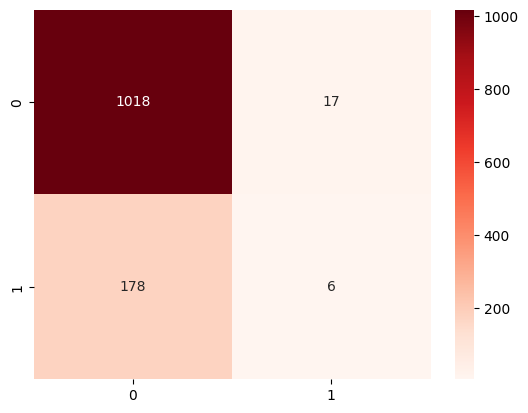

In [111]:
import seaborn as sns
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True,cmap="Reds",fmt="d")

## 🔴 Étape 8 — Le `classification_report`… avec les arguments INVERSÉS

```python
print(classification_report(y_pred, y_test))   # ← ordre FAUX !
```

La convention sklearn est `classification_report(y_true, y_pred)` — la **réalité d'abord**. Ici c'est inversé. Contrairement à la RMSE (symétrique), ça a de **vraies conséquences** :

### Ce que l'inversion fausse, point par point
1. **precision ↔ recall échangés** : la colonne affichée « precision » contient en réalité le **rappel**, et vice-versa. (La précision divise par les prédictions, le rappel par la réalité — inverser les arguments échange les deux dénominateurs !)
2. **`support` faussé** : il compte normalement les VRAIS exemplaires de chaque classe ; ici il compte les **prédictions**.
3. **L'accuracy reste juste** (elle compare paire par paire — symétrique).

### 🔍 La preuve par les chiffres affichés (fais le raisonnement avec moi)
Le rapport affiche `support = 23` pour la classe 1. Or le test contient 1219 candidats dont ~15 % d'admis → il devrait y avoir **~180 vrais admis**, pas 23 ! Ce « 23 » est le nombre de fois où le modèle a PRÉDIT « Admit ». Preuve directe de l'inversion.

### La lecture corrigée (en ré-échangeant les colonnes)
- **Vrai rappel classe Admit = 0.03** → le modèle ne retrouve que **3 % des vrais admis** !
- **Vraie précision classe Admit = 0.26** → quand il dit « admis », il a raison 1 fois sur 4.
- L'accuracy de 0.84 est DONC totalement trompeuse : elle est même **inférieure** à la baseline de 85 % (toujours répondre Deny) !

### Les remèdes au déséquilibre (pour aller plus loin)
`class_weight="balanced"` dans le modèle, rééquilibrage des données (sur/sous-échantillonnage), ou déplacer le seuil de décision (par défaut 0.5). *(Code non modifié — note documentaire.)*

In [112]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.98      0.85      0.91      1196
           1       0.03      0.26      0.06        23

    accuracy                           0.84      1219
   macro avg       0.51      0.56      0.49      1219
weighted avg       0.97      0.84      0.90      1219



## Étape 9 — Une vérification manuelle sur la matrice

`1019/(1019+16) ≈ 0.985` : l'auteur recalcule à la main une métrique depuis la matrice de confusion (fiable, elle). C'est la **précision de la classe Deny** : parmi les prédictions « Deny », 98.5 % étaient justes. (Logique : quasiment tout le monde est refusé, donc prédire « Deny » est rarement faux !)

**⭐ Bonne pratique illustrée :** recouper les métriques automatiques avec un calcul manuel sur la matrice — c'est d'ailleurs comme ça qu'on peut DÉTECTER l'inversion d'arguments de la cellule précédente (les chiffres ne collent pas).

## 📝 Résumé du notebook
1. **Imputation par hypothèse métier** (`race`→International, `admission`→Deny) : à documenter et questionner.
2. **Déséquilibre 85/15** : l'accuracy est piégeuse — ici 0.84, c'est MOINS BIEN que toujours répondre « Deny » !
3. 🔴 **`classification_report(y_true, y_pred)`** : la réalité D'ABORD — l'inversion échange précision et rappel.
4. Le vrai diagnostic : **3 % de rappel** sur les admis — ce modèle ne sert à rien tel quel ; il faut traiter le déséquilibre (`class_weight`, rééquilibrage, seuil).

In [115]:
print("0 pression : ", 1019/(1019+16))

0 pression :  0.9845410628019323
